# **Dataset Download Instructions**

To run this notebook, you need the Melanoma Skin Cancer Dataset. Follow these steps:

Open the following shared Kaggle link:

[Melanoma Skin Cancer Dataset](https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/data)



Download the dataset as a ZIP file to your computer.

Extract the ZIP file. You should get two main folders: train and test, each containing subfolders benign and malignant.

# **Dataset Summary and Class Distribution**

Clases detectadas: ['benign', 'malignant']

Imágenes en TRAIN:
{'benign': 5000, 'malignant': 4605}

Imágenes en TEST:
{'benign': 500, 'malignant': 500}


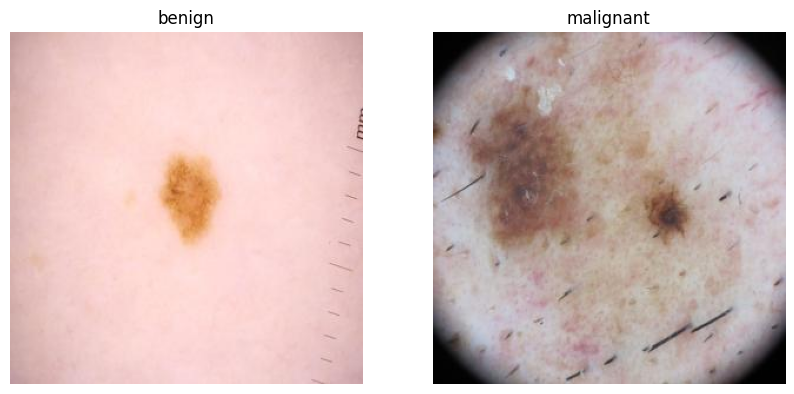

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Rutas / Change this to your actual path
train_dir = r"C:\Users\User\OneDrive - yachaytech.edu.ec\UNIVERSIDAD\OCTAVO SEMESTRE\Inteligencia Artificial\PROJECT\Teoria\archive\melanoma_cancer_dataset\train"
test_dir = r"C:\Users\User\OneDrive - yachaytech.edu.ec\UNIVERSIDAD\OCTAVO SEMESTRE\Inteligencia Artificial\PROJECT\Teoria\archive\melanoma_cancer_dataset\test"

# Clases
classes = os.listdir(train_dir)
print("Clases detectadas:", classes)

def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

print("\nImágenes en TRAIN:")
print(train_counts)

print("\nImágenes en TEST:")
print(test_counts)

def show_images(folder, num_images=5):
    plt.figure(figsize=(10,5))

    for i, cls in enumerate(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        img_name = os.listdir(cls_path)[0]
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path)

        plt.subplot(1, len(classes), i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_images(train_dir)

# **Dataset Loading with TensorFlow/Keras**

In this section, we load the melanoma image dataset into TensorFlow.
The training, validation, and test datasets are created from the directory structure.
Images are resized to 224x224, batched, and labeled for binary classification (benign vs malignant).
We also display the class names detected in the training set to verify the data.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Rutas
train_dir = r"C:\Users\User\OneDrive - yachaytech.edu.ec\UNIVERSIDAD\OCTAVO SEMESTRE\Inteligencia Artificial\PROJECT\Teoria\archive\melanoma_cancer_dataset\train"
test_dir = r"C:\Users\User\OneDrive - yachaytech.edu.ec\UNIVERSIDAD\OCTAVO SEMESTRE\Inteligencia Artificial\PROJECT\Teoria\archive\melanoma_cancer_dataset\test"

# Parámetros
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

# Dataset de entrenamiento
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Dataset de validación
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Dataset de prueba
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

# Ver clases detectadas
class_names = train_ds.class_names
print("Clases:", class_names)

Found 9605 files belonging to 2 classes.
Using 7684 files for training.
Found 9605 files belonging to 2 classes.
Using 1921 files for validation.
Found 1000 files belonging to 2 classes.
Clases: ['benign', 'malignant']


# **Data Augmentation and Visualization**

In this section, we apply data augmentation to the training images to improve model generalization.
We use random horizontal flips, rotations, zoom, and contrast adjustments.
After augmentation, we display a small grid of augmented images with their corresponding labels to visualize the transformations.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

normalization_layer = layers.Rescaling(1./255)

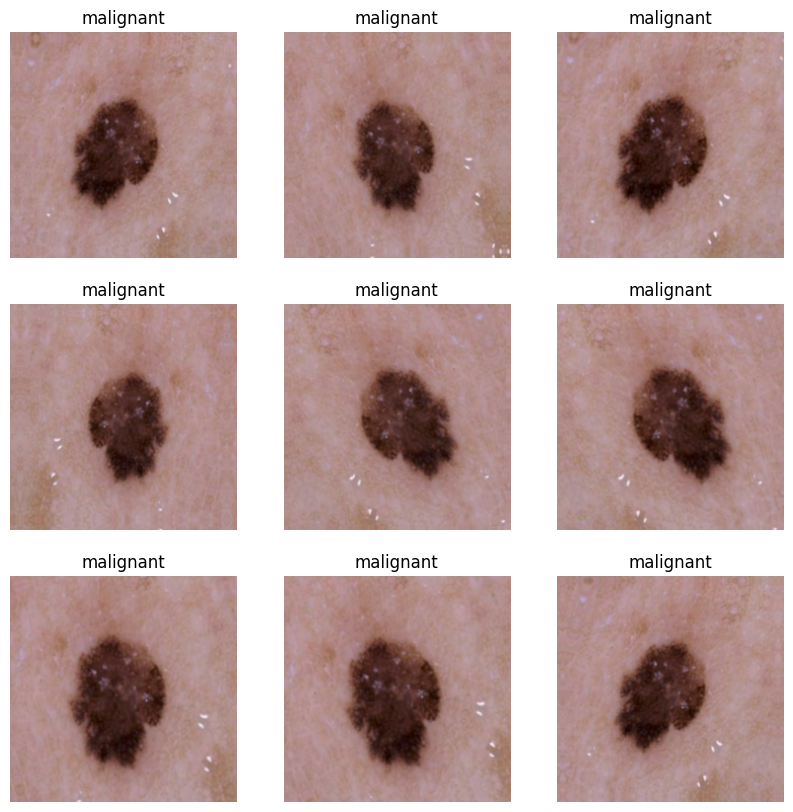

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_image = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(class_names[int(labels[0].numpy()[0])])
        plt.axis("off")

plt.show()

# **CNN Base Model**

In this section, we define a base Convolutional Neural Network (CNN) for binary classification of skin lesions (benign vs malignant).

- The model includes a **data augmentation layer** to improve generalization, applying random flips, rotations, zoom, and contrast adjustments.  
- Images are **rescaled to [0,1]** and passed through several convolutional and max-pooling layers to extract features.  
- After flattening, fully connected layers and dropout are used before the final **sigmoid output**.  
- The model is compiled with the **Adam optimizer**, binary cross-entropy loss, and metrics: **accuracy, precision, and recall**.  

This setup allows visualization of the model architecture and prepares it for training.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. CNN BASE
# =========================

model_cnn = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

# =========================
# 2. COMPILAR MODELO
# =========================

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,113 (37.48 MB)

 Trainable params: 9,826,113 (37.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# 3. ENTRENAMIENTO
# =========================

EPOCHS = 10

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 175s 718ms/step - accuracy: 0.7775 - loss: 0.4527 - precision: 0.7993 - recall: 0.7206 - val_accuracy: 0.8542 - val_loss: 0.4063 - val_precision: 0.7990 - val_recall: 0.9157
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 169s 703ms/step - accuracy: 0.8615 - loss: 0.3314 - precision: 0.8801 - recall: 0.8261 - val_accuracy: 0.8740 - val_loss: 0.2946 - val_precision: 0.9030 - val_recall: 0.8157
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 174s 721ms/step - accuracy: 0.8790 - loss: 0.2982 - precision: 0.8893 - recall: 0.8563 - val_accuracy: 0.8850 - val_loss: 0.2735 - val_precision: 0.8704 - val_recall: 0.8831
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 176s 731ms/step - accuracy: 0.8824 - loss: 0.2874 - precision: 0.8892 - recall: 0.8643 - val_accuracy: 0.8771 - val_loss: 0.2871 - val_precision: 0.9291 - val_recall: 0.7955
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 177s 735ms/step - accuracy: 0.8874 - loss: 0.2710 - precision: 0.8936 - recall: 0.8708 - val_accuracy: 0

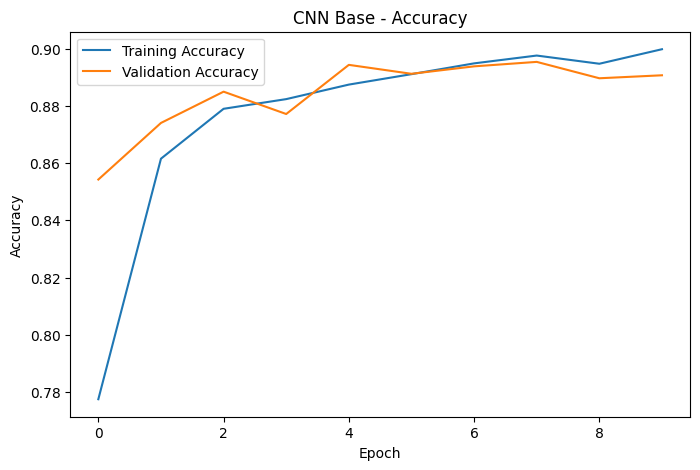

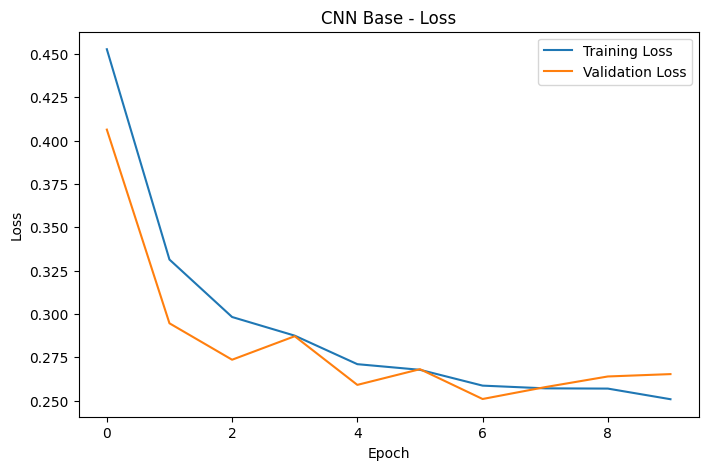

In [ ]:
# =========================
# 4. GRÁFICAS DE ENTRENAMIENTO
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Base - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Base - Loss")
plt.legend()
plt.show()

In [ ]:
# =========================
# 5. EVALUACIÓN EN TEST
# =========================

test_loss, test_acc, test_precision, test_recall = model_cnn.evaluate(test_ds)

print("Resultados CNN Base")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall/Sensibilidad: {test_recall:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9040 - loss: 0.2440 - precision: 0.9430 - recall: 0.8600
Resultados CNN Base
Test Loss: 0.2440
Test Accuracy: 0.9040
Test Precision: 0.9430
Test Recall/Sensibilidad: 0.8600


# **EfficientNet-B0 with Transfer Learning**

In this section, we define and compile an EfficientNet-B0 model pre-trained on ImageNet for binary classification of skin lesions (benign vs malignant).

- The base EfficientNet-B0 model is loaded with `include_top=False` and **pre-trained ImageNet weights**.
- The base layers are frozen to retain learned features, while we add a **global average pooling layer**, **dropout**, and a **dense sigmoid output layer** for binary classification.
- Data augmentation is applied to the inputs to improve generalization.
- The model is compiled using the **Adam optimizer**, binary cross-entropy loss, and metrics: **accuracy, precision, and recall**.
- The summary of the model is displayed to visualize the architecture.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. CONFIGURACIÓN
# =========================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 5

# =========================
# 2. MODELO BASE EfficientNet-B0
# =========================

base_model = keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Congelar capas base
base_model.trainable = False

# =========================
# 3. CONSTRUIR MODELO
# =========================

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# EfficientNet ya incluye su propio preprocesamiento interno
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_effnet = keras.Model(inputs, outputs)

# =========================
# 4. COMPILAR
# =========================

model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

model_effnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# =========================
# 5. ENTRENAR EfficientNet-B0
# =========================

history_effnet = model_effnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 210s 844ms/step - accuracy: 0.7400 - loss: 0.5428 - precision: 0.7925 - recall: 0.6261 - val_accuracy: 0.8345 - val_loss: 0.4290 - val_precision: 0.8773 - val_recall: 0.7472
Epoch 2/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 203s 843ms/step - accuracy: 0.8077 - loss: 0.4471 - precision: 0.8659 - recall: 0.7125 - val_accuracy: 0.8485 - val_loss: 0.3722 - val_precision: 0.8806 - val_recall: 0.7787
Epoch 3/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 197s 818ms/step - accuracy: 0.8346 - loss: 0.4002 - precision: 0.8812 - recall: 0.7604 - val_accuracy: 0.8589 - val_loss: 0.3440 - val_precision: 0.8854 - val_recall: 0.7989
Epoch 4/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 197s 818ms/step - accuracy: 0.8428 - loss: 0.3752 - precision: 0.8818 - recall: 0.7793 - val_accuracy: 0.8641 - val_loss: 0.3274 - val_precision: 0.8926 - val_recall: 0.8034
Epoch 5/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 198s 822ms/step - accuracy: 0.8541 - loss: 0.3588 - precision: 0.8872 - recall: 0.8000 - val_accuracy: 0.8699

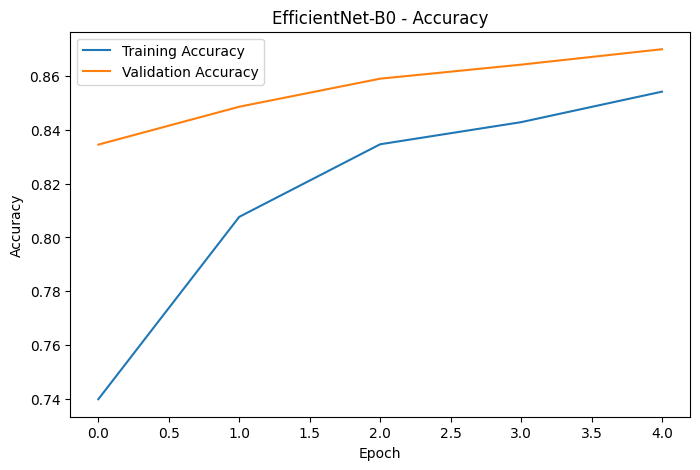

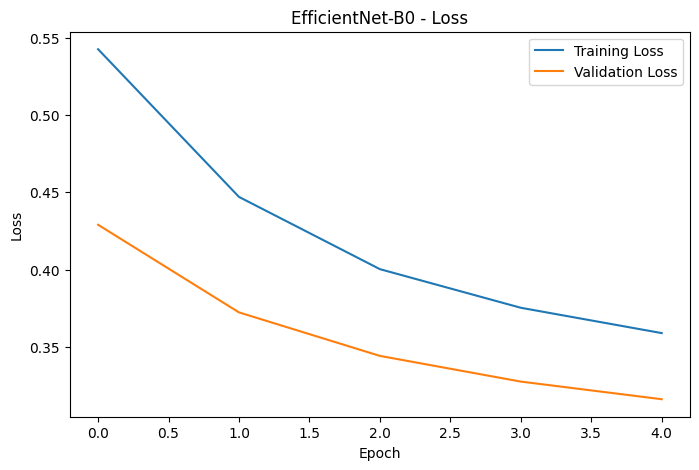

In [ ]:
# =========================
# 6. GRÁFICAS
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_effnet.history["accuracy"], label="Training Accuracy")
plt.plot(history_effnet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_effnet.history["loss"], label="Training Loss")
plt.plot(history_effnet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 - Loss")
plt.legend()
plt.show()

In [ ]:
# =========================
# 7. EVALUACIÓN EN TEST
# =========================

test_loss, test_acc, test_precision, test_recall = model_effnet.evaluate(test_ds)

print("Resultados EfficientNet-B0")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall/Sensibilidad: {test_recall:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 619ms/step - accuracy: 0.8790 - loss: 0.2887 - precision: 0.9165 - recall: 0.8340
Resultados EfficientNet-B0
Test Loss: 0.2887
Test Accuracy: 0.8790
Test Precision: 0.9165
Test Recall/Sensibilidad: 0.8340


In [ ]:
# =========================
# 8. GUARDAR MODELO
# =========================

model_effnet.save("efficientnetb0_melanoma.keras")
print("Modelo guardado como efficientnetb0_melanoma.keras")

Modelo guardado como efficientnetb0_melanoma.keras


# **EfficientNet-B0 with Fine-Tuning**

In this section, we apply Transfer Learning using EfficientNet-B0 pre-trained on ImageNet for binary classification of skin lesions (benign vs malignant).

- The base EfficientNet-B0 model is loaded without the top layer (`include_top=False`) and its weights are frozen initially.  
- Data augmentation is applied to the inputs to improve generalization.  
- A new head is added with GlobalAveragePooling2D, Dropout, and a Dense layer with sigmoid activation for binary classification.  
- The model is first trained on the new head, then fine-tuned by unfreezing the last layers of the base model.  
- The model is compiled using Adam optimizer, binary cross-entropy loss, and metrics: accuracy, precision, and recall.  
- Finally, the model is evaluated on the test dataset, and the fine-tuned model is saved for later use.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
base_model = keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_effnet = keras.Model(inputs, outputs)

In [ ]:
model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
history_effnet = model_effnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1018s 4s/step - accuracy: 0.8821 - loss: 0.2813 - precision: 0.8860 - recall: 0.8678 - val_accuracy: 0.9063 - val_loss: 0.2250 - val_precision: 0.9708 - val_recall: 0.8225
Epoch 2/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 991s 4s/step - accuracy: 0.9288 - loss: 0.1847 - precision: 0.9402 - recall: 0.9106 - val_accuracy: 0.9172 - val_loss: 0.2044 - val_precision: 0.9692 - val_recall: 0.8483
Epoch 3/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1020s 4s/step - accuracy: 0.9332 - loss: 0.1640 - precision: 0.9462 - recall: 0.9139 - val_accuracy: 0.9204 - val_loss: 0.2116 - val_precision: 0.9817 - val_recall: 0.8438
Epoch 4/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 961s 4s/step - accuracy: 0.9450 - loss: 0.1360 - precision: 0.9605 - recall: 0.9241 - val_accuracy: 0.9266 - val_loss: 0.1953 - val_precision: 0.9711 - val_recall: 0.8674
Epoch 5/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 975s 4s/step - accuracy: 0.9496 - loss: 0.1262 - precision: 0.9633 - recall: 0.9314 - val_accuracy: 0.9245 - val_loss: 

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False


In [ ]:
test_loss, test_acc, test_precision, test_recall = model_effnet.evaluate(test_ds)

print("Resultados EfficientNet-B0 Fine-Tuned")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 647ms/step - accuracy: 0.9130 - loss: 0.2644 - precision: 0.9791 - recall: 0.8440
Resultados EfficientNet-B0 Fine-Tuned
Accuracy: 0.9130
Precision: 0.9791
Recall: 0.8440


In [ ]:
model_effnet.save("efficientnetb0_final.keras")

# **Model Evaluation and Verification**

In this section, we evaluate the trained EfficientNet-B0 model on the test dataset.

- Predictions are obtained for all test images.  
- A threshold (e.g., 0.3) is applied to convert probabilities into binary labels (benign vs malignant).  
- True labels and predicted labels are collected to compute performance metrics.  
- We generate a **classification report** showing precision, recall, F1-score, and support for each class.  
- This provides a clear quantitative assessment of the model's performance on unseen data.

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_effnet.predict(images)

    # CAMBIO DE THRESHOLD
    preds = (preds > 0.3).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      benign       0.88      0.97      0.92       500
   malignant       0.96      0.86      0.91       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.91      1000
weighted avg       0.92      0.92      0.91      1000



# **Inspecting Internal Layers of the Model**

In this section, we explore the internal structure of the trained EfficientNet-B0 model:

- We print all the layers of the model along with their types to understand the architecture.
- We identify the base model inside the full model to focus on convolutional layers.
- A helper function `find_last_conv_layer` is defined to locate the last convolutional layer within the base model.
- This inspection is useful for tasks such as feature visualization or implementing Grad-CAM for explainability.


In [ ]:
for layer in model.layers:
    print(layer.name, type(layer))

print("\nCapas internas EfficientNet:")
base = None
for layer in model.layers:
    if isinstance(layer, keras.Model):
        base = layer
        break

for layer in base.layers:
    if "conv" in layer.name.lower():
        print(layer.name)

input_layer_5 <class 'keras.src.layers.core.input_layer.InputLayer'>
data_augmentation <class 'keras.src.models.sequential.Sequential'>
efficientnetb0 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d_1 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
dropout_2 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_3 <class 'keras.src.layers.core.dense.Dense'>

Capas internas EfficientNet:


In [ ]:
def find_last_conv_layer(model):
    base = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            base = layer
            break

    if base is None:
        raise ValueError("No se encontró el modelo base dentro del modelo principal.")

    for layer in reversed(base.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            print("Última capa convolucional encontrada:", layer.name)
            return base, layer.name

    raise ValueError("No se encontró ninguna capa Conv2D.")

# **Grad-CAM Visualization**

Grad-CAM (Gradient-weighted Class Activation Mapping) allows us to identify the regions in the image that contribute most to the model's decision.

- This technique provides visual interpretability and helps validate the model's decisions.
- It is particularly useful for analyzing skin lesions, as it highlights areas that influenced the prediction of benign or malignant classes.
- The generated heatmaps overlay the important regions on the original image for easy visual inspection.

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Probabilidad de maligno: 0.4469
Predicción final: Maligno
Capa usada para Grad-CAM: top_activation


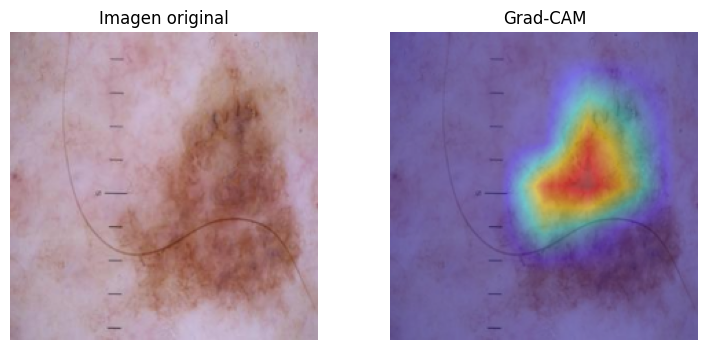

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2

model = keras.models.load_model("efficientnetb0_final.keras")

def get_img_array(img_path, size=(224, 224)):
    img = keras.utils.load_img(img_path, target_size=size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

def find_last_4d_layer(base_model):
    for layer in reversed(base_model.layers):
        try:
            if len(layer.output.shape) == 4:
                print("Capa usada para Grad-CAM:", layer.name)
                return layer.name
        except:
            pass
    raise ValueError("No se encontró capa 4D.")

def make_gradcam_heatmap(img_array, model):
    base_model = model.get_layer("efficientnetb0")
    last_layer_name = find_last_4d_layer(base_model)

    base_grad_model = keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_layer_name).output,
            base_model.output
        ]
    )

    gap_layer = None
    dense_layer = None

    for layer in model.layers:
        if isinstance(layer, keras.layers.GlobalAveragePooling2D):
            gap_layer = layer
        if isinstance(layer, keras.layers.Dense):
            dense_layer = layer

    if gap_layer is None or dense_layer is None:
        raise ValueError("No se encontraron las capas finales del modelo.")

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = base_grad_model(img_array, training=False)
        x = gap_layer(base_outputs)
        predictions = dense_layer(x)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)
    if max_value != 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        heatmap_color, alpha,
        img, 1 - alpha,
        0
    )

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    superimposed_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(9, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_rgb)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

img_path = r"C:\Users\User\OneDrive - yachaytech.edu.ec\UNIVERSIDAD\OCTAVO SEMESTRE\Inteligencia Artificial\PROJECT\Teoria\archive\melanoma_cancer_dataset\test\malignant\melanoma_10105.jpg"

img_array = get_img_array(img_path)

pred = model.predict(img_array)[0][0]

THRESHOLD = 0.3
label = "Maligno" if pred > THRESHOLD else "Benigno"

print(f"Probabilidad de maligno: {pred:.4f}")
print(f"Predicción final: {label}")

heatmap = make_gradcam_heatmap(img_array, model)
display_gradcam(img_path, heatmap)

# **Confusion Matrix and Final Metrics**

In this section, we evaluate the trained EfficientNet-B0 model on the test dataset:

- Predictions are generated for all test images using a defined threshold (e.g., 0.3) to convert probabilities into binary labels (benign vs malignant).  
- We compute the **classification report**, showing precision, recall, F1-score, and support for each class.  
- The **Confusion Matrix** is displayed as a heatmap for easy visualization of true vs predicted labels.  
- The **ROC curve** is plotted to assess the trade-off between True Positive Rate and False Positive Rate, and the AUC (Area Under the Curve) is calculated to measure overall model performance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

THRESHOLD = 0.3

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = model.predict(images)

    y_prob.extend(preds.flatten())
    y_pred.extend((preds.flatten() > THRESHOLD).astype(int))
    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

# **Confusion Matrix**

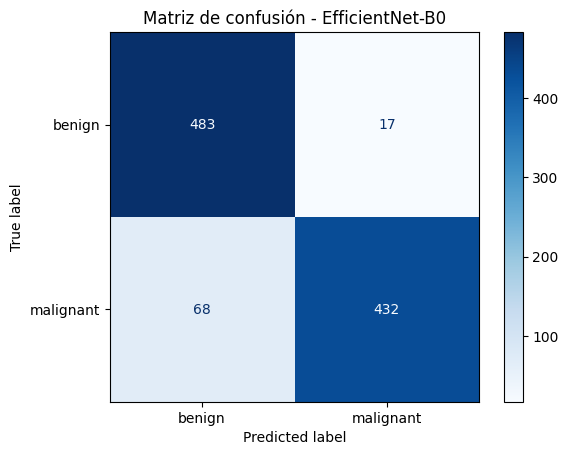

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - EfficientNet-B0")
plt.show()

# **ROC curve**

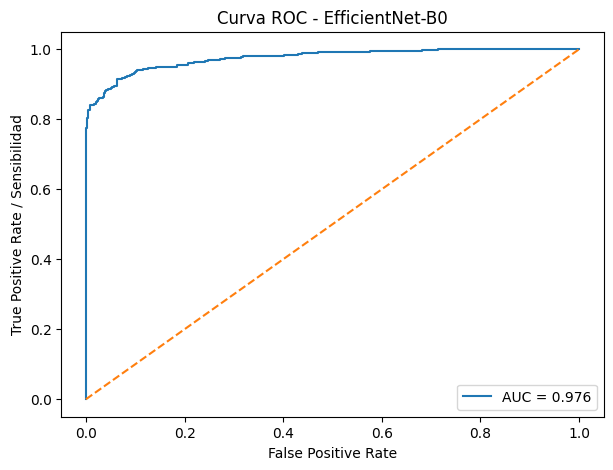

AUC: 0.9756


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensibilidad")
plt.title("Curva ROC - EfficientNet-B0")
plt.legend()
plt.show()

print(f"AUC: {roc_auc:.4f}")

# **How to Run the Streamlit Application**

This section explains step by step how to launch the melanoma detection application using Streamlit.

**Open Terminal**

Open the terminal (Command Prompt on Windows, Terminal on Mac/Linux) or the console in your IDE.

**Navigate to the App Folder**

Use the `cd` command to go to the folder containing the `app.py` file:

```bash
cd path/to/your/app/folder

# **Run the App Locally**
Execute the following command in your terminal to launch the app:

```bash
python -m streamlit run app.py

Optional: Access App from Other Devices

If you want the app to be accessible from other devices on the same network, run:

```bash
python -m streamlit run app.py --server.address 0.0.0.0